In [13]:
# import libraies
import os
import pandas as pd
import numpy as np
import joblib
import time
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
import platform
import psutil
from sklearn.metrics import accuracy_score


------------------------------------------------------------
Timing Report for Small
------------------------------------------------------------

DATASET OVERVIEW
Original Test Shape   : (1919, 44)
Processed Test Shape  : (1919, 42)

Feature Information:
Number of Features    : 42
Number of Samples     : 1919
Run 1: 0.218987 seconds
Run 2: 0.283608 seconds
Run 3: 0.253273 seconds
Run 4: 0.241350 seconds
Run 5: 0.272591 seconds

All times: [0.218987, 0.283608, 0.253273, 0.24135, 0.272591]
Best time   : 0.218987 seconds
Average time: 0.253962 seconds
Worst time  : 0.283608 seconds

Raw Predictions (first 30) - Small:
[ 1  1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1]

Converted Predictions (first 30) - Small:
[0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]

Anomaly Scores (first 10) - Small:
[  2.880718   1.762612   3.012108   5.536849  -0.553802 -10.211575
   3.591258   4.217563   6.439766   2.712704]

Statistics (Predicted only)

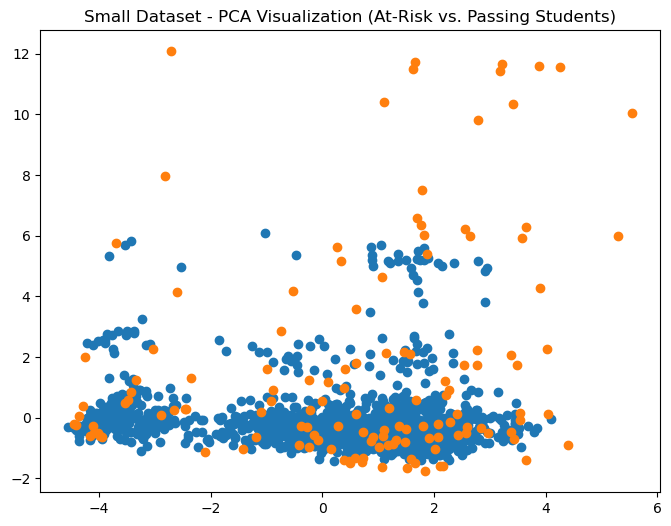


------------------------------------------------------------
Timing Report for Average
------------------------------------------------------------

DATASET OVERVIEW
Original Test Shape   : (2878, 44)
Processed Test Shape  : (2878, 42)

Feature Information:
Number of Features    : 42
Number of Samples     : 2878
Run 1: 0.518177 seconds
Run 2: 0.420820 seconds
Run 3: 0.487816 seconds
Run 4: 0.396494 seconds
Run 5: 0.526868 seconds

All times: [0.518177, 0.42082, 0.487816, 0.396494, 0.526868]
Best time   : 0.396494 seconds
Average time: 0.470035 seconds
Worst time  : 0.526868 seconds

Raw Predictions (first 30) - Average:
[ 1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1]

Converted Predictions (first 30) - Average:
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Anomaly Scores (first 10) - Average:
[ 4.416372  8.284139 13.656961 10.576367  3.330202 -2.220527 19.917451
  7.946048  3.302763  6.238682]

Statistics (Predicted only):


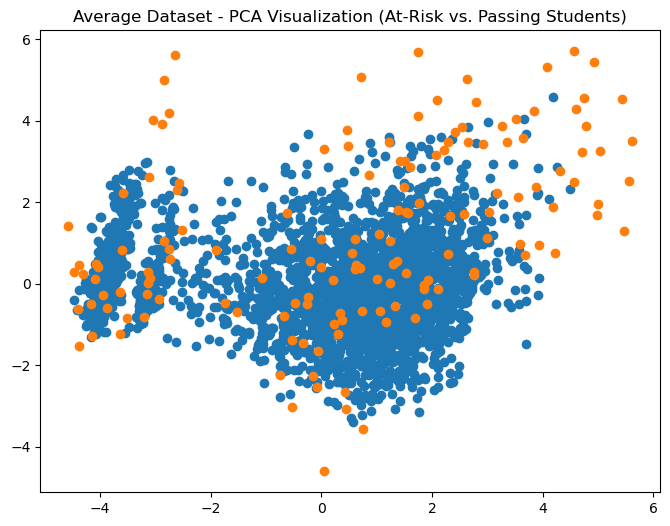


------------------------------------------------------------
Timing Report for Large
------------------------------------------------------------

DATASET OVERVIEW
Original Test Shape   : (5756, 44)
Processed Test Shape  : (5756, 42)

Feature Information:
Number of Features    : 42
Number of Samples     : 5756
Run 1: 1.758982 seconds
Run 2: 1.827314 seconds
Run 3: 1.733237 seconds
Run 4: 1.803999 seconds
Run 5: 1.851247 seconds

All times: [1.758982, 1.827314, 1.733237, 1.803999, 1.851247]
Best time   : 1.733237 seconds
Average time: 1.794956 seconds
Worst time  : 1.851247 seconds

Raw Predictions (first 30) - Large:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Converted Predictions (first 30) - Large:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Anomaly Scores (first 10) - Large:
[12.8152    5.98658   5.047107 14.562504  9.684266 36.023808  3.782175
  6.885307 29.656313 18.039621]

Statistics (Predicted only):
Total students: 5756
Predicted FAIL (a

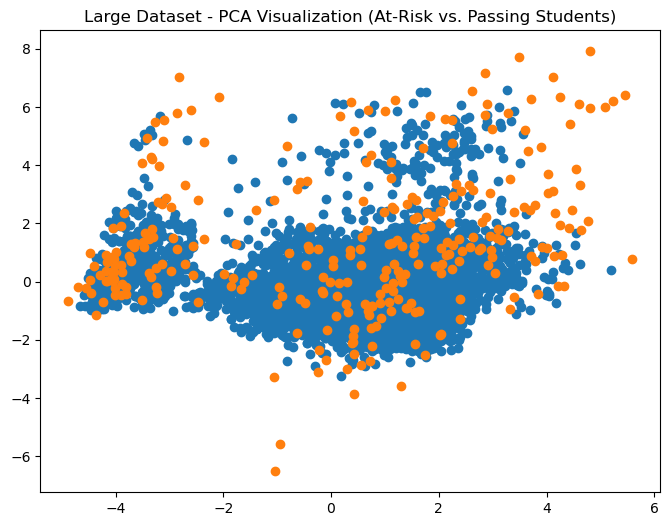

In [14]:
# base path
base_path = r"C:\Users\ariam\Downloads\splits"

datasets = {
    "Small": os.path.join(base_path, "Small", "X_test.csv"),
    "Average": os.path.join(base_path, "Average", "X_test.csv"),
    "Large": os.path.join(base_path, "Large", "X_test.csv")
}

all_summaries = []

def run_test(name, path, repeat_times=5):
    print(f"\n{'-'*60}")
    print(f"Timing Report for {name}")
    print(f"{'-'*60}")

    # Load model & scaler
    model = joblib.load(os.path.join(base_path, f"{name}_oneclass_svm_model.pkl"))
    scaler = joblib.load(os.path.join(base_path, f"{name}_scaler.pkl"))

    # Load testing data
    X_test = pd.read_csv(path)

    
    original_test = X_test.copy()

    X_test = X_test.drop(columns=["withdrew", "exam_score"], errors="ignore")
    X_test = X_test.astype(float)

    print(f"\n{'='*60}")
    print("DATASET OVERVIEW")
    print(f"{'='*60}")

    print("Original Test Shape   :", original_test.shape)
    print("Processed Test Shape  :", X_test.shape)

    print("\nFeature Information:")
    print("Number of Features    :", X_test.shape[1])
    print("Number of Samples     :", X_test.shape[0])

    X_scaled = scaler.transform(X_test)

    # Timing
    times = []
    for i in range(repeat_times):
        start = time.time()

        raw_pred = model.predict(X_scaled)
        scores = model.decision_function(X_scaled)

        end = time.time()
        elapsed = end - start
        times.append(elapsed)

        print(f"Run {i+1}: {elapsed:.6f} seconds")

    print("\nAll times:", [round(t, 6) for t in times])

    best_time = min(times)
    avg_time = np.mean(times)
    worst_time = max(times)

    print("Best time   :", round(best_time, 6), "seconds")
    print("Average time:", round(avg_time, 6), "seconds")
    print("Worst time  :", round(worst_time, 6), "seconds")

    # Save summary
    all_summaries.append({
        "Dataset": name,
        "Best Time": best_time,
        "Average Time": avg_time,
        "Worst Time": worst_time
    })

    # Predictions
    pred = np.where(raw_pred == 1, 0, 1)

    print(f"\nRaw Predictions (first 30) - {name}:")
    print(raw_pred[:30])

    print(f"\nConverted Predictions (first 30) - {name}:")
    print(pred[:30])

    print(f"\nAnomaly Scores (first 10) - {name}:")
    print(np.round(scores[:10], 6))

    # Statistics
    total = len(pred)
    fail = np.sum(pred == 1)
    pass_ = np.sum(pred == 0)

    print("\nStatistics (Predicted only):")
    print("Total students:", total)
    print("Predicted FAIL (at-risk):", fail)
    print("Predicted PASS:", pass_)
    print("Failure %:", round((fail / total) * 100, 2), "%")

    # Pseudo labels
    threshold = np.percentile(scores, 30)
    y_true_pseudo = np.where(scores <= threshold, 1, 0)

    print(f"\nConfusion Matrix ({name}):")
    print(confusion_matrix(y_true_pseudo, pred))

    print(f"\nClassification Report ({name}):")
    print(classification_report(y_true_pseudo, pred))

    # BEST / AVG / WORST cases for each example
    results = X_test.copy()
    results["score"] = scores
    results["prediction"] = pred

    best_case = results.sort_values(by="score", ascending=False).head(10)
    worst_case = results.sort_values(by="score", ascending=True).head(10)

    mid = len(results) // 2
    average_case = results.sort_values(by="score").iloc[mid-5:mid+5]

    print("\nBest Case:")
    print(best_case[["score", "prediction"]])

    print("\nAverage Case:")
    print(average_case[["score", "prediction"]])

    print("\nWorst Case:")
    print(worst_case[["score", "prediction"]])

    # Save files inside dataset folder
    dataset_folder = os.path.dirname(path)

    results.to_csv(os.path.join(dataset_folder, f"{name}_results.csv"), index=False)
    best_case.to_csv(os.path.join(dataset_folder, f"{name}_best_case.csv"), index=False)
    average_case.to_csv(os.path.join(dataset_folder, f"{name}_average_case.csv"), index=False)
    worst_case.to_csv(os.path.join(dataset_folder, f"{name}_worst_case.csv"), index=False)

    print("\nFiles saved successfully!")

    # PCA
    if X_scaled.shape[1] >= 2:
        pca = PCA(n_components=2)
        X_2d = pca.fit_transform(X_scaled)

        plt.figure(figsize=(8,6))
        plt.scatter(X_2d[pred==0,0], X_2d[pred==0,1])
        plt.scatter(X_2d[pred==1,0], X_2d[pred==1,1])

        plt.title(f"{name} Dataset - PCA Visualization (At-Risk vs. Passing Students)")
        plt.show()


# Run all datasets
for name, path in datasets.items():
    run_test(name, path, repeat_times=5)

In [16]:
#final timing summary
timing_df = pd.DataFrame(all_summaries)

print(f"\n{'='*60}")
print("FINAL TIMING SUMMARY")
print(f"{'='*60}")
print(timing_df)

timing_df.to_csv(os.path.join(base_path, "timing_summary.csv"), index=False)

print("\nSaved file: timing_summary.csv")


FINAL TIMING SUMMARY
   Dataset  Best Time  Average Time  Worst Time
0    Small   0.218987      0.253962    0.283608
1  Average   0.396494      0.470035    0.526868
2    Large   1.733237      1.794956    1.851247

Saved file: timing_summary.csv


In [17]:

# MACHINE INFORMATION 

print(f"\n{'='*60}")
print("MACHINE INFORMATION")
print(f"{'='*60}")

print("System       :", platform.system())
print("Release      :", platform.release())
print("Processor    :", platform.processor())
print("Architecture :", platform.machine())

# CPU
print("\nCPU Info:")
print("Physical cores :", psutil.cpu_count(logical=False))
print("Total cores    :", psutil.cpu_count(logical=True))
print("Max Frequency  :", psutil.cpu_freq().max, "MHz")

# RAM
memory = psutil.virtual_memory()
print("\nMemory Info:")
print("Total RAM:", round(memory.total / (1024**3), 2), "GB")


MACHINE INFORMATION
System       : Windows
Release      : 11
Processor    : Intel64 Family 6 Model 154 Stepping 4, GenuineIntel
Architecture : AMD64

CPU Info:
Physical cores : 10
Total cores    : 12
Max Frequency  : 1700.0 MHz

Memory Info:
Total RAM: 15.68 GB
